<a href="https://colab.research.google.com/github/MLfinal/Walmart-Recruiting---Store-Sales-Forecasting/blob/dev/models/deep_learning/tft/model_experiment_TFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# TFT experiment v7 — stable serious residual blending train

Previous TFT validation results:
- v4 residual blending: `4728.60`
- v5 fine residual blending: `4717.71`
- v6 serious full-data train: invalid validation WMAE because non-finite residual predictions propagated into WMAE

v7 keeps the corrected residual + blending approach, but makes the serious train safer and more stable.

Main changes:
- use a broad but safer panel: `top_n_series = 2000` instead of full-data `4000`;
- keep yearly context with `encoder_weeks = 52`;
- lower learning rate to `5e-5`;
- use stronger gradient clipping: `gradient_clip_val = 0.05`;
- add residual target clipping to avoid extreme correction targets;
- add prediction NaN/Inf diagnostics before evaluation;
- replace non-finite residual predictions with `0.0` before WMAE so one bad prediction cannot invalidate the whole run;
- clip final sales predictions into a realistic non-negative range.

The model still predicts residuals:

```text
ResidualSales = Weekly_Sales - SeasonalNaive52
Prediction(alpha) = SeasonalNaive52 + alpha * PredictedResidual
```

Blending remains important because TFT residuals can over-correct the seasonal baseline.



In [4]:
%pip install -q "torch>=2.3,<3" "pytorch-forecasting>=1.2,<2" "lightning>=2.2,<3" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "scikit-learn>=1.4,<2" "cloudpickle>=3,<4"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 54.1 MB/s eta 0:00:00


In [5]:
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import hashlib
import json
import math
from pathlib import Path

import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wandb

try:
    from lightning.pytorch import Trainer, seed_everything
    from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
    from lightning.pytorch.loggers import WandbLogger
except Exception:
    from pytorch_lightning import Trainer, seed_everything
    from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
    from pytorch_lightning.loggers import WandbLogger

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE

pd.set_option('display.max_columns', 120)
print('torch', torch.__version__)
print('cuda available:', torch.cuda.is_available())


torch 2.11.0+cu128
cuda available: True


In [7]:
SEED = 42
seed_everything(SEED, workers=True)

CONFIG = {
    "seed": SEED,
    "validation_weeks": 39,
    "encoder_weeks": 52,
    "top_n_series": 2000,
    "holiday_weight": 5.0,
    "batch_size": 512,
    "max_epochs": 45,
    "max_time_minutes": 240,
    "patience": 7,
    "learning_rate": 5e-5,
    "hidden_size": 24,
    "attention_head_size": 2,
    "dropout": 0.15,
    "hidden_continuous_size": 12,
    "gradient_clip_val": 0.05,
    "residual_clip": 100000.0,
    "prediction_clip_max": 300000.0,
    "num_workers": 0,
    "limit_train_batches": 1.0,
    "limit_val_batches": 1.0,
    "blend_alphas": [0.25, 0.30, 0.35, 0.40, 0.45, 0.50],
    "baseline_top300_wmae": 7801.898566783023,
    "v1_top500_wmae": 6200.954359119016,
    "v1_top500_seasonal_naive_wmae": 4969.768735310006,
    "v2_top500_wmae": 6524.679969182181,
    "v5_best_blend_wmae": 4717.71,
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_entity": "kende23-n-a",
    "wandb_group": "tft-experiments",
    "run_name": "tft_v7_stable_serious_residual_blending",
    "artifact_name": "tft-v7-stable-serious-residual-blending",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "package_selected_raw_pipeline": True,
    "selected_model_artifact_uri": "kende23-n-a/Walmart-Recruiting---Store-Sales-Forecasting/tft-v7-stable-serious-residual-blending:experiment-v7",
    "raw_pipeline_artifact_name": "tft-v7-raw-input-pipeline",
    "raw_pipeline_registry_target": "wandb-registry-model/Walmart_TFT_Raw_Pipeline",
}

DATA_DIR = Path('/content/drive/MyDrive/walmart_competition_data')
OUTPUT_DIR = Path('/content/artifacts/tft_v7_stable_serious_residual_blending')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG



INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


{'seed': 42,
 'validation_weeks': 39,
 'encoder_weeks': 52,
 'top_n_series': 2000,
 'holiday_weight': 5.0,
 'batch_size': 512,
 'max_epochs': 45,
 'max_time_minutes': 240,
 'patience': 7,
 'learning_rate': 5e-05,
 'hidden_size': 24,
 'attention_head_size': 2,
 'dropout': 0.15,
 'hidden_continuous_size': 12,
 'gradient_clip_val': 0.05,
 'residual_clip': 100000.0,
 'prediction_clip_max': 300000.0,
 'num_workers': 0,
 'limit_train_batches': 1.0,
 'limit_val_batches': 1.0,
 'blend_alphas': [0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
 'baseline_top300_wmae': 7801.898566783023,
 'v1_top500_wmae': 6200.954359119016,
 'v1_top500_seasonal_naive_wmae': 4969.768735310006,
 'v2_top500_wmae': 6524.679969182181,
 'v5_best_blend_wmae': 4717.71,
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'wandb_entity': 'kende23-n-a',
 'wandb_group': 'tft-experiments',
 'run_name': 'tft_v7_stable_serious_residual_blending',
 'artifact_name': 'tft-v7-stable-serious-residual-blending',
 'device': 'cuda',


## Load data and keep a broad stable series panel

v7 does not use the full Store-Dept panel. It keeps the same filtering path, but limits training to the top `2000` highest-volume series. This is still much broader than the early top-500 experiments, while avoiding the noisiest sparse series that made the full-data v6 run unstable.



In [8]:
train_raw = pd.read_csv(DATA_DIR / 'train.csv', parse_dates=['Date'])
test_raw = pd.read_csv(DATA_DIR / 'test.csv', parse_dates=['Date'])
features_raw = pd.read_csv(DATA_DIR / 'features.csv', parse_dates=['Date'])
stores_raw = pd.read_csv(DATA_DIR / 'stores.csv')

required_train = {'Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'}
required_features = {'Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment'}
required_stores = {'Store', 'Type', 'Size'}
missing = {
    'train': sorted(required_train.difference(train_raw.columns)),
    'features': sorted(required_features.difference(features_raw.columns)),
    'stores': sorted(required_stores.difference(stores_raw.columns)),
}
if any(missing.values()):
    raise ValueError(missing)

train_raw = train_raw.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
test_raw = test_raw.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
features_raw = features_raw.sort_values(['Store', 'Date']).reset_index(drop=True)
stores_raw = stores_raw.sort_values('Store').reset_index(drop=True)

if CONFIG['top_n_series'] is not None:
    top_series = (
        train_raw.groupby(['Store', 'Dept'], as_index=False)['Weekly_Sales']
        .sum()
        .sort_values('Weekly_Sales', ascending=False)
        .head(CONFIG['top_n_series'])[['Store', 'Dept']]
    )
    before_rows = len(train_raw)
    train_raw = train_raw.merge(top_series.assign(_keep=1), on=['Store', 'Dept'], how='inner').drop(columns='_keep')
    print({'top_n_series': CONFIG['top_n_series'], 'train_rows_before': before_rows, 'train_rows_after': len(train_raw)})

print('train', train_raw.shape, train_raw['Date'].min(), train_raw['Date'].max())
print('features', features_raw.shape, features_raw['Date'].min(), features_raw['Date'].max())
print('stores', stores_raw.shape)
display(train_raw.head())


{'top_n_series': 2000, 'train_rows_before': 421570, 'train_rows_after': 285226}
train (285226, 5) 2010-02-05 00:00:00 2012-10-26 00:00:00
features (8190, 12) 2010-02-05 00:00:00 2013-07-26 00:00:00
stores (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


## Merge covariates and create log target


In [9]:
all_train_dates = pd.Index(sorted(train_raw['Date'].unique()), name='Date')
test_dates = pd.Index(sorted(test_raw['Date'].unique()), name='Date')
val_dates = all_train_dates[-CONFIG['validation_weeks']:]
fit_dates = all_train_dates[:-CONFIG['validation_weeks']]
split_pos = len(fit_dates)

if len(test_dates) != CONFIG['validation_weeks']:
    raise ValueError(f"Expected test horizon {CONFIG['validation_weeks']}, got {len(test_dates)}")
if len(fit_dates) < CONFIG['encoder_weeks'] + CONFIG['validation_weeks']:
    raise ValueError('Not enough fit history for encoder + decoder windows.')

date_to_idx = {date: idx for idx, date in enumerate(all_train_dates)}

COVARIATE_REALS = [
    'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'CPI', 'Unemployment', 'Size'
]
CALENDAR_REALS = ['time_idx', 'week_sin', 'week_cos', 'month_sin', 'month_cos']
KNOWN_REALS = CALENDAR_REALS + COVARIATE_REALS
TARGET_COL = 'ResidualSales'
SEASONAL_COL = 'SeasonalNaive52'


def build_seasonal_lookup(df: pd.DataFrame) -> pd.DataFrame:
    panel = (
        df.pivot_table(index=['Store', 'Dept'], columns='Date', values='Weekly_Sales', aggfunc='sum')
        .reindex(columns=all_train_dates)
        .fillna(0.0)
        .sort_index()
    )
    seasonal_panel = panel.shift(52, axis=1).fillna(0.0)
    lookup = seasonal_panel.stack().rename(SEASONAL_COL).reset_index()
    lookup['Store'] = lookup['Store'].astype(int)
    lookup['Dept'] = lookup['Dept'].astype(int)
    lookup['Date'] = pd.to_datetime(lookup['Date'])
    return lookup


seasonal_lookup_long = build_seasonal_lookup(train_raw)


def make_model_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.sort_values(['Store', 'Dept', 'Date']).copy()
    out['Weekly_Sales_Original'] = out['Weekly_Sales'].astype(float)
    out['Weekly_Sales_Clipped'] = out['Weekly_Sales_Original'].clip(lower=0.0)
    out = out.merge(seasonal_lookup_long, on=['Store', 'Dept', 'Date'], how='left')
    out[SEASONAL_COL] = out[SEASONAL_COL].fillna(0.0).astype(float)
    out[TARGET_COL] = (out['Weekly_Sales_Clipped'] - out[SEASONAL_COL]).astype(float)
    out[TARGET_COL] = out[TARGET_COL].clip(-CONFIG['residual_clip'], CONFIG['residual_clip'])

    feat = features_raw.drop(columns=[c for c in ['IsHoliday'] if c in features_raw.columns])
    out = out.merge(feat, on=['Store', 'Date'], how='left')
    out = out.merge(stores_raw, on='Store', how='left')

    markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
    out[markdown_cols] = out[markdown_cols].fillna(0.0)
    for col in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']:
        out[col] = out.groupby('Store')[col].transform(lambda s: s.ffill().bfill())
        out[col] = out[col].fillna(out[col].median())
    out['Size'] = out['Size'].fillna(out['Size'].median())
    out['Type'] = out['Type'].fillna('Unknown')

    out['time_idx'] = out['Date'].map(date_to_idx).astype('int64')
    iso_week = out['Date'].dt.isocalendar().week.astype(int)
    month = out['Date'].dt.month.astype(int)
    out['week_sin'] = np.sin(2 * np.pi * iso_week / 52.0)
    out['week_cos'] = np.cos(2 * np.pi * iso_week / 52.0)
    out['month_sin'] = np.sin(2 * np.pi * month / 12.0)
    out['month_cos'] = np.cos(2 * np.pi * month / 12.0)

    out['Store'] = out['Store'].astype(str)
    out['Dept'] = out['Dept'].astype(str)
    out['Type'] = out['Type'].astype(str)
    out['IsHoliday'] = out['IsHoliday'].astype(int).astype(str)
    for col in KNOWN_REALS:
        if col != 'time_idx':
            out[col] = out[col].astype(float)
    out['time_idx'] = out['time_idx'].astype('int64')
    return out


data = make_model_frame(train_raw)
val_seasonal_values = data.loc[data['Date'].isin(val_dates), SEASONAL_COL].to_numpy(dtype=float)

print({
    'n_rows': len(data),
    'n_series': data[['Store', 'Dept']].drop_duplicates().shape[0],
    'n_dates': len(all_train_dates),
    'fit_range': (str(fit_dates.min().date()), str(fit_dates.max().date())),
    'validation_range': (str(val_dates.min().date()), str(val_dates.max().date())),
    'target': TARGET_COL,
    'time_idx_dtype': str(data['time_idx'].dtype),
    'validation_seasonal_min': float(np.min(val_seasonal_values)),
    'validation_seasonal_mean': float(np.mean(val_seasonal_values)),
    'validation_seasonal_max': float(np.max(val_seasonal_values)),
    'residual_min': float(data[TARGET_COL].min()),
    'residual_mean': float(data[TARGET_COL].mean()),
    'residual_max': float(data[TARGET_COL].max()),
})
if float(np.mean(val_seasonal_values)) <= 0:
    raise ValueError('SeasonalNaive52 is zero in validation; residual setup is invalid.')

display(data[['Store', 'Dept', 'Date', 'Weekly_Sales_Original', 'Weekly_Sales_Clipped', SEASONAL_COL, TARGET_COL, 'IsHoliday'] + KNOWN_REALS[:5]].head())
display(data.loc[data['Date'].isin(val_dates), ['Store', 'Dept', 'Date', 'Weekly_Sales_Original', SEASONAL_COL, TARGET_COL]].head())



{'n_rows': 285226, 'n_series': 2000, 'n_dates': 143, 'fit_range': ('2010-02-05', '2012-01-27'), 'validation_range': ('2012-02-03', '2012-10-26'), 'target': 'ResidualSales', 'time_idx_dtype': 'int64', 'validation_seasonal_min': -1321.48, 'validation_seasonal_mean': 22361.151392688193, 'validation_seasonal_max': 241120.0, 'residual_min': -100000.0, 'residual_mean': 8295.834959120133, 'residual_max': 100000.0}


,Store,Dept,Date,Weekly_Sales_Original,Weekly_Sales_Clipped,SeasonalNaive52,ResidualSales,IsHoliday,time_idx,week_sin,week_cos,month_sin,month_cos
0,1,1,2010-02-05,24924.50,24924.50,0.0,24924.50,0,0,0.568065,0.822984,0.866025,5.000000e-01
1,1,1,2010-02-12,46039.49,46039.49,0.0,46039.49,1,1,0.663123,0.748511,0.866025,5.000000e-01
2,1,1,2010-02-19,41595.55,41595.55,0.0,41595.55,0,2,0.748511,0.663123,0.866025,5.000000e-01
3,1,1,2010-02-26,19403.54,19403.54,0.0,19403.54,0,3,0.822984,0.568065,0.866025,5.000000e-01
4,1,1,2010-03-05,21827.90,21827.90,0.0,21827.90,0,4,0.885456,0.464723,1.000000,6.123234e-17


,Store,Dept,Date,Weekly_Sales_Original,SeasonalNaive52,ResidualSales
104,1,1,2012-02-03,23510.49,21665.76,1844.73
105,1,1,2012-02-10,36988.49,37887.17,-898.68
106,1,1,2012-02-17,54060.10,46845.87,7214.23
107,1,1,2012-02-24,20124.22,19363.83,760.39
108,1,1,2012-03-02,20113.03,20327.61,-214.58


## WMAE and seasonal naive on original sales scale


In [10]:
def wmae(y_true: np.ndarray, y_pred: np.ndarray, is_holiday: np.ndarray, holiday_weight: float = 5.0) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))

sales_panel = (
    train_raw.pivot_table(index=['Store', 'Dept'], columns='Date', values='Weekly_Sales', aggfunc='sum')
    .reindex(columns=all_train_dates)
    .fillna(0.0)
    .sort_index()
)
holiday_by_date = (
    train_raw[['Date', 'IsHoliday']]
    .drop_duplicates('Date')
    .set_index('Date')
    .reindex(all_train_dates)['IsHoliday']
    .fillna(False)
    .astype(bool)
)
values = sales_panel.to_numpy(dtype=np.float32)
holiday_flags = holiday_by_date.to_numpy(dtype=bool)
actual_val = values[:, split_pos:split_pos + CONFIG['validation_weeks']]
seasonal_naive = values[:, split_pos - 52:split_pos - 52 + CONFIG['validation_weeks']]
val_holidays_matrix = np.tile(holiday_flags[split_pos:split_pos + CONFIG['validation_weeks']], (values.shape[0], 1))
seasonal_naive_wmae = wmae(actual_val.ravel(), seasonal_naive.ravel(), val_holidays_matrix.ravel(), CONFIG['holiday_weight'])
print({'n_series': len(sales_panel), 'seasonal_naive_wmae': seasonal_naive_wmae})


{'n_series': 2000, 'seasonal_naive_wmae': 2488.0334056017514}


## Create TFT datasets/loaders


In [11]:
training_cutoff = split_pos - 1

training_dataset = TimeSeriesDataSet(
    data[data.time_idx <= training_cutoff],
    time_idx='time_idx',
    min_prediction_idx=52,
    target=TARGET_COL,
    group_ids=['Store', 'Dept'],
    min_encoder_length=CONFIG['encoder_weeks'] // 2,
    max_encoder_length=CONFIG['encoder_weeks'],
    min_prediction_length=CONFIG['validation_weeks'],
    max_prediction_length=CONFIG['validation_weeks'],
    static_categoricals=['Store', 'Dept', 'Type'],
    time_varying_known_categoricals=['IsHoliday'],
    time_varying_known_reals=KNOWN_REALS,
    time_varying_unknown_reals=[TARGET_COL],
    target_normalizer=GroupNormalizer(groups=['Store', 'Dept'], center=True),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)
validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    data,
    predict=True,
    stop_randomization=True,
    min_prediction_idx=split_pos,
)
train_loader = training_dataset.to_dataloader(train=True, batch_size=CONFIG['batch_size'], num_workers=CONFIG['num_workers'])
val_loader = validation_dataset.to_dataloader(train=False, batch_size=CONFIG['batch_size'], num_workers=CONFIG['num_workers'])
print({
    'train_batches_total': len(train_loader),
    'validation_batches_total': len(val_loader),
    'training_samples': len(training_dataset),
    'validation_samples': len(validation_dataset),
    'effective_train_batches_per_epoch': min(len(train_loader), CONFIG['limit_train_batches']),
})


{'train_batches_total': 155, 'validation_batches_total': 4, 'training_samples': 79679, 'validation_samples': 2000, 'effective_train_batches_per_epoch': 1.0}


## W&B setup


In [12]:
baseline_model = Baseline()
_ = baseline_model.predict(val_loader, return_y=True)
print('PyTorch Forecasting Baseline object ran successfully.')

if wandb.run is not None:
    wandb.finish()

wandb_logger = WandbLogger(
    project=CONFIG['wandb_project'],
    entity=CONFIG['wandb_entity'],
    group=CONFIG['wandb_group'],
    name=CONFIG['run_name'],
    job_type='experiment_train',
    log_model=False,
    config=CONFIG,
)
run = wandb_logger.experiment
run.config.update({
    'n_series': int(data[['Store', 'Dept']].drop_duplicates().shape[0]),
    'n_train_rows': int(len(data[data.time_idx <= training_cutoff])),
    'n_validation_rows': int(len(data[data.time_idx >= split_pos])),
    'fit_start': str(fit_dates.min().date()),
    'fit_end': str(fit_dates.max().date()),
    'validation_start': str(val_dates.min().date()),
    'validation_end': str(val_dates.max().date()),
    'seasonal_naive_wmae': float(seasonal_naive_wmae),
    'known_reals': json.dumps(KNOWN_REALS),
    'target_strategy': 'seasonal_residual_52w',
}, allow_val_change=True)


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

PyTorch Forecasting Baseline object ran successfully.


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Build and train TFT v3


In [ ]:
checkpoint_callback = ModelCheckpoint(
    dirpath=str(OUTPUT_DIR / 'checkpoints'),
    filename='tft-v7-{epoch:02d}-{val_loss:.4f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
)
early_stop_callback = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=CONFIG['patience'], mode='min')
lr_monitor = LearningRateMonitor(logging_interval='epoch')

tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=CONFIG['learning_rate'],
    hidden_size=CONFIG['hidden_size'],
    attention_head_size=CONFIG['attention_head_size'],
    dropout=CONFIG['dropout'],
    hidden_continuous_size=CONFIG['hidden_continuous_size'],
    loss=MAE(),
    optimizer='adam',
    log_interval=20,
    reduce_on_plateau_patience=3,
)
print(f'Number of parameters: {tft.size() / 1e3:.1f}k')
run.summary['model_parameters'] = int(tft.size())

trainer = Trainer(
    max_epochs=CONFIG['max_epochs'],
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    gradient_clip_val=CONFIG['gradient_clip_val'],
    callbacks=[early_stop_callback, checkpoint_callback, lr_monitor],
    logger=wandb_logger,
    enable_checkpointing=True,
    limit_train_batches=CONFIG['limit_train_batches'],
    limit_val_batches=CONFIG['limit_val_batches'],
    max_time={"minutes": CONFIG['max_time_minutes']},
    log_every_n_steps=20,
)
trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

best_checkpoint_path = checkpoint_callback.best_model_path
best_val_loss = float(checkpoint_callback.best_model_score.cpu()) if checkpoint_callback.best_model_score is not None else math.nan
print({'best_checkpoint_path': best_checkpoint_path, 'best_val_loss': best_val_loss})
run.summary['best_checkpoint_path'] = best_checkpoint_path
run.summary['best_val_loss'] = best_val_loss



/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

Number of parameters: 81.6k


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MAE                             │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  1.8 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    480 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  4.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 23.7 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 22.1 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  2.4 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  2.4 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  2.4 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  2.4 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  4.8 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  4.8 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  1.2 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     48 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  3.0 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  1.8 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  1.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  2.4 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  1.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     25 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 81.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 81.6 K                                                                                               
Total estimated model params size (MB): 0.326                                                                      
Modules in train mode: 705                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

{'best_checkpoint_path': '/content/artifacts/tft_v7_stable_serious_residual_blending/checkpoints/tft-v7-epoch=01-val_loss=2830.1372.ckpt', 'best_val_loss': 2830.13720703125}


## Evaluate validation WMAE with stable residual blending

The model predicts residuals. We first inspect raw residual predictions for NaN/Inf values, then apply a safe post-processing step:

```text
PredictedResidual = nan_to_num(PredictedResidual, 0.0)
PredictedResidual = clip(PredictedResidual, -residual_clip, residual_clip)
Prediction = clip(SeasonalNaive52 + alpha * PredictedResidual, 0, prediction_clip_max)
```

This does not make a bad model look good. It only prevents one non-finite prediction from turning the whole WMAE into `NaN`.



In [13]:
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_checkpoint_path)
best_tft.eval()

prediction = best_tft.predict(
    val_loader,
    mode='prediction',
    return_index=True,
    return_y=True,
    trainer_kwargs={'accelerator': 'gpu' if torch.cuda.is_available() else 'cpu', 'devices': 1},
)
pred_residual = prediction.output.detach().cpu().numpy() if torch.is_tensor(prediction.output) else np.asarray(prediction.output)
index_df = prediction.index.reset_index(drop=True).copy()
if pred_residual.ndim == 3:
    pred_residual = pred_residual[..., 0]
if pred_residual.shape[1] != CONFIG['validation_weeks']:
    raise ValueError(f"Expected prediction horizon {CONFIG['validation_weeks']}, got {pred_residual.shape}")

finite_mask = np.isfinite(pred_residual)
finite_values = pred_residual[finite_mask]
prediction_diagnostics = {
    'raw_prediction_nan_count': int(np.isnan(pred_residual).sum()),
    'raw_prediction_posinf_count': int(np.isposinf(pred_residual).sum()),
    'raw_prediction_neginf_count': int(np.isneginf(pred_residual).sum()),
    'raw_prediction_finite_count': int(finite_mask.sum()),
    'raw_prediction_total_count': int(pred_residual.size),
    'raw_prediction_min_finite': float(np.min(finite_values)) if finite_values.size else math.nan,
    'raw_prediction_mean_finite': float(np.mean(finite_values)) if finite_values.size else math.nan,
    'raw_prediction_max_finite': float(np.max(finite_values)) if finite_values.size else math.nan,
}
print(prediction_diagnostics)

pred_residual = np.nan_to_num(pred_residual, nan=0.0, posinf=0.0, neginf=0.0)
pred_residual = np.clip(pred_residual, -CONFIG['residual_clip'], CONFIG['residual_clip'])
prediction_diagnostics.update({
    'postprocessed_prediction_min': float(np.min(pred_residual)),
    'postprocessed_prediction_mean': float(np.mean(pred_residual)),
    'postprocessed_prediction_max': float(np.max(pred_residual)),
})

actual_lookup = sales_panel.copy()
seasonal_lookup = (
    seasonal_lookup_long
    .pivot_table(index=['Store', 'Dept'], columns='Date', values=SEASONAL_COL, aggfunc='first')
    .reindex(index=sales_panel.index, columns=all_train_dates)
    .fillna(0.0)
)
validation_seasonal_matrix = seasonal_lookup.loc[:, val_dates].to_numpy(dtype=float)
print({
    'eval_seasonal_min': float(np.min(validation_seasonal_matrix)),
    'eval_seasonal_mean': float(np.mean(validation_seasonal_matrix)),
    'eval_seasonal_max': float(np.max(validation_seasonal_matrix)),
    'seasonal_naive_wmae_check': float(seasonal_naive_wmae),
})
if float(np.mean(validation_seasonal_matrix)) <= 0:
    raise ValueError('Evaluation seasonal baseline is zero; refusing invalid residual evaluation.')

records = []
for row_idx, row in index_df.iterrows():
    store = int(row['Store'])
    dept = int(row['Dept'])
    if (store, dept) not in actual_lookup.index:
        continue
    for horizon_idx, date in enumerate(val_dates):
        actual = float(actual_lookup.loc[(store, dept), date])
        seasonal_base = float(seasonal_lookup.loc[(store, dept), date])
        residual_pred = float(pred_residual[row_idx, horizon_idx])
        full_pred = float(np.clip(seasonal_base + residual_pred, 0.0, CONFIG['prediction_clip_max']))
        is_holiday = bool(holiday_by_date.loc[date])
        records.append({
            'Store': store,
            'Dept': dept,
            'Date': pd.Timestamp(date),
            'IsHoliday': is_holiday,
            'Weekly_Sales': actual,
            'SeasonalNaive52': seasonal_base,
            'PredictedResidual': residual_pred,
            'Prediction': full_pred,
            'AbsError': abs(actual - full_pred),
        })
val_pred_df = pd.DataFrame(records)
if val_pred_df.empty:
    raise ValueError('No validation predictions were aligned.')

if not np.isfinite(val_pred_df[['Weekly_Sales', 'SeasonalNaive52', 'PredictedResidual', 'Prediction']].to_numpy()).all():
    raise ValueError('Non-finite values remain after prediction post-processing.')

validation_wmae = wmae(val_pred_df['Weekly_Sales'], val_pred_df['Prediction'], val_pred_df['IsHoliday'], CONFIG['holiday_weight'])
improvement_vs_seasonal = 100.0 * (seasonal_naive_wmae - validation_wmae) / seasonal_naive_wmae
improvement_vs_v1 = 100.0 * (CONFIG['v1_top500_wmae'] - validation_wmae) / CONFIG['v1_top500_wmae']
improvement_vs_v2 = 100.0 * (CONFIG['v2_top500_wmae'] - validation_wmae) / CONFIG['v2_top500_wmae']
improvement_vs_v5 = 100.0 * (CONFIG['v5_best_blend_wmae'] - validation_wmae) / CONFIG['v5_best_blend_wmae']

blend_rows = []
for alpha in CONFIG['blend_alphas']:
    pred_col = f'PredictionAlpha_{alpha:.2f}'
    err_col = f'AbsErrorAlpha_{alpha:.2f}'
    val_pred_df[pred_col] = np.clip(
        val_pred_df['SeasonalNaive52'] + alpha * val_pred_df['PredictedResidual'],
        0.0,
        CONFIG['prediction_clip_max'],
    )
    val_pred_df[err_col] = np.abs(val_pred_df['Weekly_Sales'] - val_pred_df[pred_col])
    alpha_wmae = wmae(val_pred_df['Weekly_Sales'], val_pred_df[pred_col], val_pred_df['IsHoliday'], CONFIG['holiday_weight'])
    blend_rows.append({
        'alpha': float(alpha),
        'wmae': float(alpha_wmae),
        'improvement_vs_seasonal_naive_pct': float(100.0 * (seasonal_naive_wmae - alpha_wmae) / seasonal_naive_wmae),
        'improvement_vs_full_residual_pct': float(100.0 * (validation_wmae - alpha_wmae) / validation_wmae),
        'improvement_vs_v5_pct': float(100.0 * (CONFIG['v5_best_blend_wmae'] - alpha_wmae) / CONFIG['v5_best_blend_wmae']),
    })

blend_results_df = pd.DataFrame(blend_rows).sort_values('wmae').reset_index(drop=True)
best_blend = blend_results_df.iloc[0].to_dict()
best_alpha = float(best_blend['alpha'])
best_alpha_suffix = f'{best_alpha:.2f}'
val_pred_df['BestBlendAlpha'] = best_alpha
val_pred_df['BestBlendPrediction'] = val_pred_df[f'PredictionAlpha_{best_alpha_suffix}']
val_pred_df['BestBlendAbsError'] = val_pred_df[f'AbsErrorAlpha_{best_alpha_suffix}']

print({
    'validation_wmae_full_residual_alpha_1': validation_wmae,
    'seasonal_naive_wmae': seasonal_naive_wmae,
    'improvement_vs_seasonal_naive_pct': improvement_vs_seasonal,
    'improvement_vs_v1_pct': improvement_vs_v1,
    'improvement_vs_v2_pct': improvement_vs_v2,
    'improvement_vs_v5_pct': improvement_vs_v5,
    'best_blend_alpha': best_alpha,
    'best_blend_wmae': float(best_blend['wmae']),
    'best_blend_improvement_vs_seasonal_naive_pct': float(best_blend['improvement_vs_seasonal_naive_pct']),
    'best_blend_improvement_vs_v5_pct': float(best_blend['improvement_vs_v5_pct']),
    'prediction_rows': len(val_pred_df),
    **prediction_diagnostics,
})
display(blend_results_df)

run.summary['best_validation_wmae'] = float(validation_wmae)
run.summary['seasonal_naive_wmae'] = float(seasonal_naive_wmae)
run.summary['best_improvement_vs_seasonal_naive_pct'] = float(improvement_vs_seasonal)
run.summary['improvement_vs_v1_pct'] = float(improvement_vs_v1)
run.summary['improvement_vs_v2_pct'] = float(improvement_vs_v2)
run.summary['improvement_vs_v5_pct'] = float(improvement_vs_v5)
run.summary['best_blend_alpha'] = best_alpha
run.summary['best_blend_wmae'] = float(best_blend['wmae'])
run.summary['best_blend_improvement_vs_seasonal_naive_pct'] = float(best_blend['improvement_vs_seasonal_naive_pct'])
run.summary['best_blend_improvement_vs_full_residual_pct'] = float(best_blend['improvement_vs_full_residual_pct'])
run.summary['best_blend_improvement_vs_v5_pct'] = float(best_blend['improvement_vs_v5_pct'])
for key, value in prediction_diagnostics.items():
    run.summary[key] = value
wandb.log({
    'validation/wmae': float(validation_wmae),
    'validation/seasonal_naive_wmae': float(seasonal_naive_wmae),
    'validation/improvement_vs_seasonal_naive_pct': float(improvement_vs_seasonal),
    'validation/improvement_vs_v1_pct': float(improvement_vs_v1),
    'validation/improvement_vs_v2_pct': float(improvement_vs_v2),
    'validation/improvement_vs_v5_pct': float(improvement_vs_v5),
    'validation/best_blend_alpha': best_alpha,
    'validation/best_blend_wmae': float(best_blend['wmae']),
    'validation/best_blend_improvement_vs_seasonal_naive_pct': float(best_blend['improvement_vs_seasonal_naive_pct']),
    'validation/best_blend_improvement_vs_full_residual_pct': float(best_blend['improvement_vs_full_residual_pct']),
    'validation/best_blend_improvement_vs_v5_pct': float(best_blend['improvement_vs_v5_pct']),
    'validation/blend_results': wandb.Table(dataframe=blend_results_df),
    **{f'prediction_diagnostics/{k}': v for k, v in prediction_diagnostics.items()},
})
display(val_pred_df.head())



NameError: name 'best_checkpoint_path' is not defined

## Save artifacts to W&B


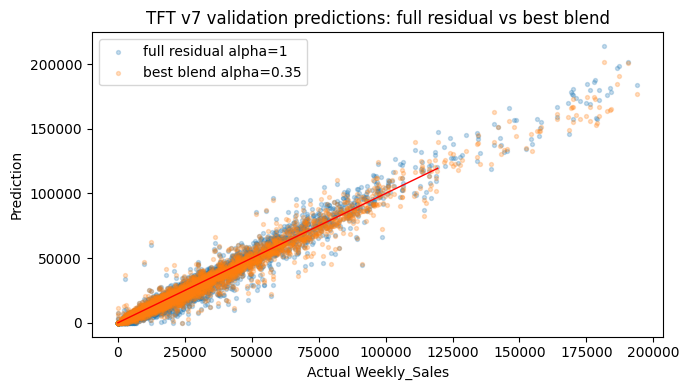

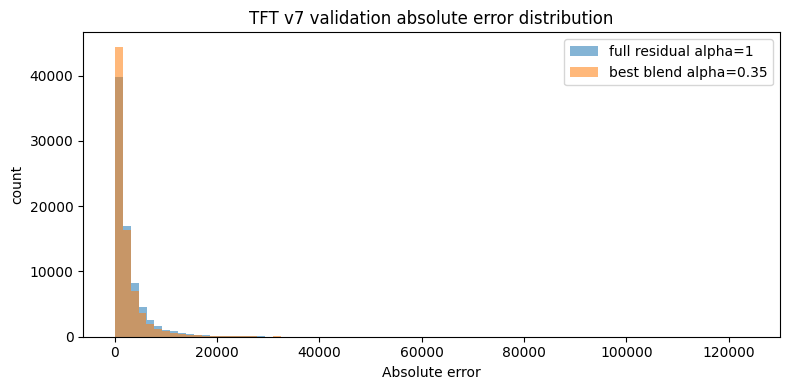

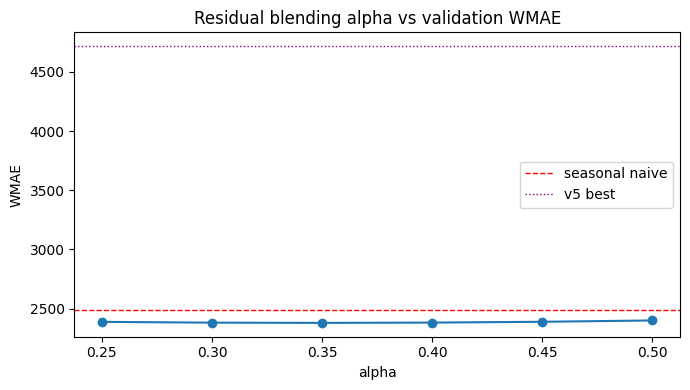

{'model': 'TemporalFusionTransformer',
 'experiment': 'tft_v7_stable_serious_residual_blending',
 'target_strategy': 'seasonal_residual_52w_clipped',
 'postprocess_strategy': 'nan_safe_residual_blending',
 'best_checkpoint_path': '/content/artifacts/tft_v7_stable_serious_residual_blending/checkpoints/tft-v7-epoch=01-val_loss=2830.1372.ckpt',
 'best_val_loss': 2830.13720703125,
 'full_residual_validation_wmae': 2736.1381252132073,
 'seasonal_naive_wmae': 2488.0334056017514,
 'full_residual_improvement_vs_seasonal_naive_pct': -9.97192075688589,
 'improvement_vs_v1_pct': 55.87553194631259,
 'improvement_vs_v2_pct': 58.06479186509186,
 'improvement_vs_v5_pct': 42.00283346765258,
 'blend_alphas': [0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
 'best_blend_alpha': 0.35,
 'best_blend_wmae': 2379.5014331629395,
 'best_blend_improvement_vs_seasonal_naive_pct': 4.36215897240184,
 'best_blend_improvement_vs_full_residual_pct': 13.034308785945436,
 'best_blend_improvement_vs_v5_pct': 49.562363240577746,
 'pre

In [ ]:
val_pred_path = OUTPUT_DIR / 'tft_v7_validation_predictions.csv'
blend_results_path = OUTPUT_DIR / 'tft_v7_residual_blending_results.csv'
best_blend_pred_path = OUTPUT_DIR / 'tft_v7_best_blended_validation_predictions.csv'

val_pred_df.to_csv(val_pred_path, index=False)
blend_results_df.to_csv(blend_results_path, index=False)
val_pred_df[[
    'Store', 'Dept', 'Date', 'IsHoliday', 'Weekly_Sales', 'SeasonalNaive52',
    'PredictedResidual', 'BestBlendAlpha', 'BestBlendPrediction', 'BestBlendAbsError'
]].to_csv(best_blend_pred_path, index=False)

summary = {
    'model': 'TemporalFusionTransformer',
    'experiment': 'tft_v7_stable_serious_residual_blending',
    'target_strategy': 'seasonal_residual_52w_clipped',
    'postprocess_strategy': 'nan_safe_residual_blending',
    'best_checkpoint_path': str(best_checkpoint_path),
    'best_val_loss': best_val_loss,
    'full_residual_validation_wmae': float(validation_wmae),
    'seasonal_naive_wmae': float(seasonal_naive_wmae),
    'full_residual_improvement_vs_seasonal_naive_pct': float(improvement_vs_seasonal),
    'improvement_vs_v1_pct': float(improvement_vs_v1),
    'improvement_vs_v2_pct': float(improvement_vs_v2),
    'improvement_vs_v5_pct': float(improvement_vs_v5),
    'blend_alphas': CONFIG['blend_alphas'],
    'best_blend_alpha': float(best_alpha),
    'best_blend_wmae': float(best_blend['wmae']),
    'best_blend_improvement_vs_seasonal_naive_pct': float(best_blend['improvement_vs_seasonal_naive_pct']),
    'best_blend_improvement_vs_full_residual_pct': float(best_blend['improvement_vs_full_residual_pct']),
    'best_blend_improvement_vs_v5_pct': float(best_blend['improvement_vs_v5_pct']),
    'prediction_diagnostics': prediction_diagnostics,
    'validation_weeks': CONFIG['validation_weeks'],
    'encoder_weeks': CONFIG['encoder_weeks'],
    'top_n_series': CONFIG['top_n_series'],
    'n_series': int(data[['Store', 'Dept']].drop_duplicates().shape[0]),
    'known_reals': KNOWN_REALS,
    'config': CONFIG,
}
summary_path = OUTPUT_DIR / 'tft_v7_summary.json'
summary_path.write_text(json.dumps(summary, indent=2))

fig, ax = plt.subplots(figsize=(7,4))
sample = val_pred_df.sample(min(7000, len(val_pred_df)), random_state=SEED)
ax.scatter(sample['Weekly_Sales'], sample['Prediction'], s=8, alpha=0.25, label='full residual alpha=1')
ax.scatter(sample['Weekly_Sales'], sample['BestBlendPrediction'], s=8, alpha=0.25, label=f'best blend alpha={best_alpha:.2f}')
max_axis = np.nanpercentile(sample[['Weekly_Sales', 'Prediction', 'BestBlendPrediction']].to_numpy(), 99)
ax.plot([0, max_axis], [0, max_axis], color='red', linewidth=1)
ax.set_title('TFT v7 validation predictions: full residual vs best blend')
ax.set_xlabel('Actual Weekly_Sales')
ax.set_ylabel('Prediction')
ax.legend()
plt.tight_layout()
scatter_path = OUTPUT_DIR / 'tft_v7_validation_scatter.png'
fig.savefig(scatter_path, dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(val_pred_df['AbsError'], bins=80, alpha=0.55, label='full residual alpha=1')
ax.hist(val_pred_df['BestBlendAbsError'], bins=80, alpha=0.55, label=f'best blend alpha={best_alpha:.2f}')
ax.set_title('TFT v7 validation absolute error distribution')
ax.set_xlabel('Absolute error')
ax.set_ylabel('count')
ax.legend()
plt.tight_layout()
error_hist_path = OUTPUT_DIR / 'tft_v7_abs_error_hist.png'
fig.savefig(error_hist_path, dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(blend_results_df.sort_values('alpha')['alpha'], blend_results_df.sort_values('alpha')['wmae'], marker='o')
ax.axhline(seasonal_naive_wmae, color='red', linestyle='--', linewidth=1, label='seasonal naive')
ax.axhline(CONFIG['v5_best_blend_wmae'], color='purple', linestyle=':', linewidth=1, label='v5 best')
ax.set_title('Residual blending alpha vs validation WMAE')
ax.set_xlabel('alpha')
ax.set_ylabel('WMAE')
ax.legend()
plt.tight_layout()
blend_plot_path = OUTPUT_DIR / 'tft_v7_residual_blending_curve.png'
fig.savefig(blend_plot_path, dpi=160)
plt.show()

artifact = wandb.Artifact(CONFIG['artifact_name'], type='model')
artifact.add_file(str(best_checkpoint_path), name='tft_v7_best.ckpt')
artifact.add_file(str(summary_path))
artifact.add_file(str(val_pred_path))
artifact.add_file(str(blend_results_path))
artifact.add_file(str(best_blend_pred_path))
artifact.add_file(str(scatter_path))
artifact.add_file(str(error_hist_path))
artifact.add_file(str(blend_plot_path))
run.log_artifact(artifact, aliases=['experiment-v7', 'stable-residual-blending', 'latest'])
wandb.log({
    'validation/prediction_table': wandb.Table(dataframe=val_pred_df.sample(min(20000, len(val_pred_df)), random_state=SEED)),
    'validation/best_blend_prediction_table': wandb.Table(dataframe=val_pred_df[[
        'Store', 'Dept', 'Date', 'IsHoliday', 'Weekly_Sales', 'SeasonalNaive52',
        'PredictedResidual', 'BestBlendAlpha', 'BestBlendPrediction', 'BestBlendAbsError'
    ]].sample(min(20000, len(val_pred_df)), random_state=SEED)),
    'validation/blend_results_table': wandb.Table(dataframe=blend_results_df),
    'validation/scatter': wandb.Image(str(scatter_path)),
    'validation/abs_error_histogram': wandb.Image(str(error_hist_path)),
    'validation/residual_blending_curve': wandb.Image(str(blend_plot_path)),
})
summary



In [ ]:
wandb.finish()


epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇███
lr-Adam,██████▁▁▁
prediction_diagnostics/postprocessed_prediction_max,▁
prediction_diagnostics/postprocessed_prediction_mean,▁
prediction_diagnostics/postprocessed_prediction_min,▁
prediction_diagnostics/raw_prediction_finite_count,▁
prediction_diagnostics/raw_prediction_max_finite,▁
prediction_diagnostics/raw_prediction_mean_finite,▁
prediction_diagnostics/raw_prediction_min_finite,▁
prediction_diagnostics/raw_prediction_nan_count,▁
+22,...


## Package selected TFT as a raw-input pipeline

This package-only section does not train. It combines the selected v7 checkpoint, fitted `TimeSeriesDataSet`, full historical sales, feature tables, top-series policy and fallback logic into one `predict(raw_test)` artifact.


In [14]:
class TFTRawPipeline:
    """Self-contained v7 TFT residual-blending pipeline accepting raw Walmart test rows."""
    required_raw_columns = {"Store", "Dept", "Date", "IsHoliday"}

    def __init__(self, model, training_dataset, full_train_raw, features_table, stores_table, top_series, config):
        self.model = model.cpu().eval()
        self.training_dataset = training_dataset
        self.full_train_raw = full_train_raw[["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]].copy()
        self.full_train_raw["Date"] = pd.to_datetime(self.full_train_raw["Date"])
        self.features_table = features_table.copy()
        self.features_table["Date"] = pd.to_datetime(self.features_table["Date"])
        self.stores_table = stores_table.copy()
        self.top_series = top_series[["Store", "Dept"]].copy()
        self.config = dict(config)
        self.covariate_reals = ["Temperature", "Fuel_Price", "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5", "CPI", "Unemployment", "Size"]
        self.known_reals = ["time_idx", "week_sin", "week_cos", "month_sin", "month_cos", *self.covariate_reals]

    def _add_features(self, frame, date_to_idx):
        out = frame.merge(self.features_table.drop(columns=["IsHoliday"], errors="ignore"), on=["Store", "Date"], how="left")
        out = out.merge(self.stores_table, on="Store", how="left")
        markdown = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
        out[markdown] = out[markdown].fillna(0.0)
        for col in ["Temperature", "Fuel_Price", "CPI", "Unemployment"]:
            out[col] = out.groupby("Store")[col].transform(lambda s: s.ffill().bfill()).fillna(out[col].median())
        out["Size"] = out["Size"].fillna(out["Size"].median())
        out["Type"] = out["Type"].fillna("Unknown")
        out["time_idx"] = out["Date"].map(date_to_idx).astype("int64")
        week = out["Date"].dt.isocalendar().week.astype(int)
        month = out["Date"].dt.month.astype(int)
        out["week_sin"] = np.sin(2 * np.pi * week / 52.0)
        out["week_cos"] = np.cos(2 * np.pi * week / 52.0)
        out["month_sin"] = np.sin(2 * np.pi * month / 12.0)
        out["month_cos"] = np.cos(2 * np.pi * month / 12.0)
        out["Store"] = out["Store"].astype(str)
        out["Dept"] = out["Dept"].astype(str)
        out["Type"] = out["Type"].astype(str)
        out["IsHoliday"] = out["IsHoliday"].astype(int).astype(str)
        for col in self.known_reals:
            if col != "time_idx": out[col] = out[col].astype(float)
        return out

    def predict(self, raw_test):
        missing = self.required_raw_columns.difference(raw_test.columns)
        if missing: raise ValueError({"missing_raw_test_columns": sorted(missing)})
        test = raw_test.copy(); test["Date"] = pd.to_datetime(test["Date"])
        test_dates = pd.Index(sorted(test["Date"].unique()), name="Date")
        if len(test_dates) != int(self.config["validation_weeks"]): raise ValueError("Unexpected test horizon")
        train = self.full_train_raw.copy()
        dates = pd.Index(sorted(set(train["Date"].unique()).union(set(test_dates))), name="Date")
        date_to_idx = {date: idx for idx, date in enumerate(dates)}
        top_keys = set(map(tuple, self.top_series[["Store", "Dept"]].to_numpy()))
        train_top = train.merge(self.top_series.assign(_keep=1), on=["Store", "Dept"], how="inner").drop(columns="_keep")
        test_top = test[test.apply(lambda r: (int(r.Store), int(r.Dept)) in top_keys, axis=1)].copy()
        full_panel = train.pivot_table(index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum").reindex(columns=dates).fillna(0.0)
        top_panel = train_top.pivot_table(index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum").reindex(columns=dates).fillna(0.0)
        full_seasonal = full_panel.shift(52, axis=1).fillna(0.0)
        top_seasonal = top_panel.shift(52, axis=1).fillna(0.0)
        lookup = top_seasonal.stack().rename("SeasonalNaive52").reset_index()
        lookup["Date"] = pd.to_datetime(lookup["Date"])
        history = train_top.copy(); history["Weekly_Sales_Clipped"] = history["Weekly_Sales"].clip(lower=0.0)
        history = history.merge(lookup, on=["Store", "Dept", "Date"], how="left").fillna({"SeasonalNaive52":0.0})
        history["ResidualSales"] = (history["Weekly_Sales_Clipped"] - history["SeasonalNaive52"]).clip(-self.config["residual_clip"], self.config["residual_clip"])
        future_lookup = lookup[lookup["Date"].isin(test_dates)]
        future = test_top.merge(future_lookup, on=["Store", "Dept", "Date"], how="left").fillna({"SeasonalNaive52":0.0})
        future["ResidualSales"] = 0.0
        predict_frame = pd.concat([self._add_features(history, date_to_idx), self._add_features(future, date_to_idx)], ignore_index=True).sort_values(["Store","Dept","Date"])
        test_start_idx = int(date_to_idx[test_dates.min()])
        dataset = TimeSeriesDataSet.from_dataset(self.training_dataset, predict_frame, predict=True, stop_randomization=True, min_prediction_idx=test_start_idx)
        loader = dataset.to_dataloader(train=False, batch_size=int(self.config["batch_size"]), num_workers=0)
        prediction = self.model.predict(loader, mode="prediction", return_index=True, trainer_kwargs={"accelerator":"cpu","devices":1})
        residual = prediction.output.detach().cpu().numpy() if torch.is_tensor(prediction.output) else np.asarray(prediction.output)
        if residual.ndim == 3: residual = residual[...,0]
        residual = np.clip(np.nan_to_num(residual, nan=0.0, posinf=0.0, neginf=0.0), -self.config["residual_clip"], self.config["residual_clip"])
        tft_lookup = {}
        for i, row in prediction.index.reset_index(drop=True).iterrows():
            for h, date in enumerate(test_dates):
                base = float(top_seasonal.loc[(int(row.Store), int(row.Dept)), date])
                tft_lookup[(int(row.Store), int(row.Dept), pd.Timestamp(date))] = float(np.clip(base + self.config["best_blend_alpha"] * residual[i,h], 0.0, self.config["prediction_clip_max"]))
        output = []
        for row in test.itertuples(index=False):
            key = (int(row.Store), int(row.Dept), pd.Timestamp(row.Date))
            fallback = float(full_seasonal.loc[(int(row.Store), int(row.Dept)), pd.Timestamp(row.Date)]) if (int(row.Store), int(row.Dept)) in full_seasonal.index else 0.0
            output.append(tft_lookup.get(key, max(0.0, fallback)))
        return np.asarray(output, dtype=np.float32)

    def metadata(self):
        return {"pipeline_type":type(self).__name__, "top_n_series":int(len(self.top_series)), "stored_history_rows":int(len(self.full_train_raw)), "blend_alpha":float(self.config["best_blend_alpha"]), "raw_input_columns":sorted(self.required_raw_columns), "fallback":"SeasonalNaive52 for non-top/cold-start series"}


In [15]:
if CONFIG["package_selected_raw_pipeline"]:
    package_run = wandb.init(project=CONFIG["wandb_project"], entity=CONFIG["wandb_entity"], group="tft-pipeline-packaging", job_type="pipeline_packaging", name="tft_v7_raw_pipeline_registration")
    source_artifact = package_run.use_artifact(CONFIG["selected_model_artifact_uri"], type="model")
    source_dir = Path(source_artifact.download(root=str(OUTPUT_DIR / "selected_source_model")))
    checkpoint_candidates = sorted(source_dir.glob("*.ckpt"))
    if not checkpoint_candidates: raise FileNotFoundError(f"No .ckpt in {source_dir}")
    selected_model = TemporalFusionTransformer.load_from_checkpoint(str(checkpoint_candidates[0]), loss=MAE()).cpu().eval()
    full_train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"]).sort_values(["Store","Dept","Date"]).reset_index(drop=True)
    pipeline = TFTRawPipeline(selected_model, training_dataset, full_train_raw, features_raw, stores_raw, top_series, {**CONFIG, "best_blend_alpha":0.35})
    pipeline_path = OUTPUT_DIR / "walmart_tft_raw_pipeline.pkl"
    with pipeline_path.open("wb") as f: cloudpickle.dump(pipeline, f)
    first = pipeline.predict(test_raw)
    with pipeline_path.open("rb") as f: reloaded = cloudpickle.load(f)
    second = reloaded.predict(test_raw)
    if len(first) != len(test_raw) or not np.isfinite(first).all() or (first < 0).any() or not np.allclose(first, second, rtol=0, atol=1e-5): raise AssertionError("TFT raw pipeline contract test failed")
    contract = test_raw[["Store","Dept","Date"]].copy(); contract["Weekly_Sales"] = first
    contract_path = OUTPUT_DIR / "tft_raw_pipeline_contract_predictions.csv"; contract.to_csv(contract_path,index=False)
    manifest = {"source_model_artifact":source_artifact.name, "source_model_artifact_uri":CONFIG["selected_model_artifact_uri"], "registry_target":CONFIG["raw_pipeline_registry_target"], "contract_rows":int(len(first)), "prediction_sha256":hashlib.sha256(first.tobytes()).hexdigest(), **pipeline.metadata()}
    manifest_path = OUTPUT_DIR / "tft_raw_pipeline_manifest.json"; manifest_path.write_text(json.dumps(manifest,indent=2))
    artifact = wandb.Artifact(CONFIG["raw_pipeline_artifact_name"], type="model", description="Self-contained TFT v7 raw-input residual-blending pipeline.", metadata=manifest)
    for p in [pipeline_path, contract_path, manifest_path]: artifact.add_file(str(p))
    package_run.log_artifact(artifact, aliases=["tft-v7","latest"])
    package_run.link_artifact(artifact, target_path=CONFIG["raw_pipeline_registry_target"], aliases=["champion","tft-v7","latest"])
    package_run.log({"pipeline/contract_predictions":wandb.Table(dataframe=contract.head(2000))}); package_run.summary.update(manifest); package_run.finish()
    print({"registry_target":CONFIG["raw_pipeline_registry_target"], **pipeline.metadata()})
else: print("Pipeline packaging skipped")


wandb:   8 of 8 files downloaded.  
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 18 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__Store': '1', '__group_id__Dept': '18'}, {'_

blend_alpha,0.35
contract_rows,115064
fallback,SeasonalNaive52 for ...
pipeline_type,TFTRawPipeline
prediction_sha256,96e1018a7573866f81b7...
registry_target,wandb-registry-model...
source_model_artifact,tft-v7-stable-seriou...
source_model_artifact_uri,kende23-n-a/Walmart-...
stored_history_rows,421570
top_n_series,2000


{'registry_target': 'wandb-registry-model/Walmart_TFT_Raw_Pipeline', 'pipeline_type': 'TFTRawPipeline', 'top_n_series': 2000, 'stored_history_rows': 421570, 'blend_alpha': 0.35, 'raw_input_columns': ['Date', 'Dept', 'IsHoliday', 'Store'], 'fallback': 'SeasonalNaive52 for non-top/cold-start series'}
